In [6]:
import os
from sdf_fitter_2d_utils import *
import trimesh

def fit_in_bbox(vertices):
    
    min_vals = np.min(vertices, axis=0)
    max_vals = np.max(vertices, axis=0)
    
    # Shift the vertices by subtracting the minimum values for each axis
    vertices = vertices - min_vals

    ranges = max_vals - min_vals
    scale = 1.0 / np.max(ranges)
    print(scale)
    
    # Scale the shifted vertices so that the largest extent in any axis is 1
    vertices = vertices * scale
    
    vertices = 2 * vertices - 1

    new_min_vals = np.min(vertices, axis=0)
    new_max_vals = np.max(vertices, axis=0)

    vertices = vertices - (new_min_vals+new_max_vals)/2
    
    return vertices

In [7]:
shape_name = 'shark'

In [8]:
OBJ_PATH = 'data/curves/'+shape_name+'_bdry.obj'  # <-- set to e.g. "curve.obj" or leave None to use demo circle polyline
mesh = trimesh.load(OBJ_PATH)
V = fit_in_bbox(mesh.vertices)

print(V[:,0].min(), V[:,0].max())
print(V[:,1].min(), V[:,1].max())
print(V[:,2].min(), V[:,2].max())

mesh.vertices=V
mesh.export(OBJ_PATH);

0.5
-1.0 1.0
-0.42627328 0.42627328
0.0 0.0


In [9]:


# --- Main loading section ---
if OBJ_PATH is None or not os.path.exists(OBJ_PATH):
    print("OBJ not provided or not found. Using demo circle polyline.")
    poly = make_circle_polyline(radius=1.0, n=256)
    poly = np.vstack([poly, poly[0:1]])  # demo is explicitly closed
else:
    poly = load_polyline_obj(OBJ_PATH)
    print(f"Loaded closed polyline with {len(poly)} vertices (wrap last→first).")

# sample training data
pts, sdf_vals = sample_training_points(poly, n_outside=3000, n_oncurve=3000, padding=0.2)
# fit network
#model, device = fit_sdf_network(pts, sdf_vals, hidden=128, layers=4, lr=1e-3, epochs=10000, print_every=50)



Loaded closed polyline with 570 vertices (wrap last→first).


In [5]:
# plot results
plot_results( pts, sdf_vals, model=model, device=device, grid_res=300, polyline=poly)

NameError: name 'model' is not defined

In [6]:

import torch
# Save model weights
WEIGHTS_PATH = "sdf_weights/curves/"+shape_name+".pth"

torch.save(model.state_dict(), WEIGHTS_PATH)
print(f"Model weights saved to {WEIGHTS_PATH}")


NameError: name 'model' is not defined

In [10]:
import torch

WEIGHTS_PATH = "sdf_weights/curves/"+shape_name+".pth"


# Recreate the same model architecture
model, device = fit_sdf_network(
    pts[:1], sdf_vals[:1],  # dummy tiny dataset, just to build structure
    hidden=128, layers=4, epochs=0  # zero epochs, we’ll load weights
)

# Load weights
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
model.eval()  # set to inference mode
print("Model weights loaded.")

Model weights loaded.


/var/folders/3s/dfq9yqvd6y9303d_mb00rpxw0000gp/T/ipykernel_64472/2771220410.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(WEIGHTS_PAT

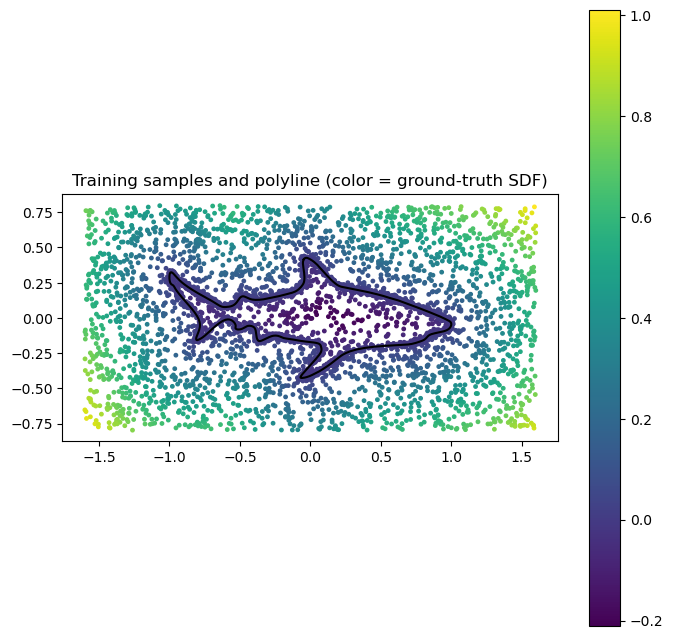

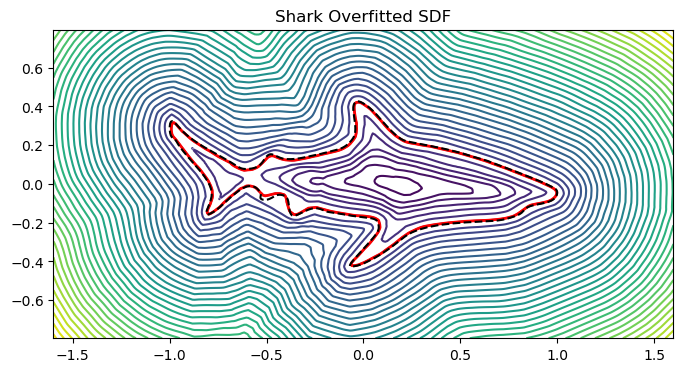

In [11]:
plot_results( pts, sdf_vals, model=model, device=device, grid_res=300, polyline=poly)

In [12]:
import inspect

inspect.getfile(plot_results)

'/Users/romywilliamson/Documents/BNS/bns/sdf_fitter_2d_utils.py'